# Assignment Part 2

# This are the Library that i have imported for now to use

In [1]:
#Imported Library to be used here
import pandas as pd
pd.set_option('display.max_colwidth',None)
import os
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

import seaborn as sns

# import Decision Tree
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

#Importing the lib for exporting
import pickle
from datetime import datetime
import os

#import SVM 
from sklearn.svm import SVC

from sklearn.naive_bayes import MultinomialNB

from sklearn.linear_model import LogisticRegression


**Imported the cleaned dataset to use for model training from part 1.**

In [3]:
df = pd.read_csv('Data/234707R_cleaned_data.csv') #imported the data and converted it to Data Frame
df

,species,processed_words
0,Javan Myna,javan myna share similarity common myna term physical appearance however distinguish frontal
1,Collared Kingfisher,click information red list category criterion justification red list category specie extremely large range hence approach threshold vulnerable range size criterion extent occurrence combine decline fluctuate range size habitat extent quality population size small number
2,Black-naped Oriole,blackheade oriole oriolus larvatus specie bird family oriolidae find africa strike appearance bright yellow body contrast black head fleshcoloure beak taxonomy systematic edit authority consider mountain oriole subspecie blackheade
3,Javan Myna,search thousand royaltyfree javan myna stock image video next project download royaltyfree stock photo vector footage adobe stock
4,Little Egret,foreground recording background recording egretta garzetta total record duration
...,...,...
578,Black-naped Oriole,identification record blacknape oriole oriolus chinensis bird belong family oriolid order passeriforme
579,Black-naped Oriole,blacknape oriole oriolus chinensis blacknape oriole mediumsize overall golden strong pinkish bill broad black mask nape adult male central tail feather tip yellow lateral one broadly yellow female mantle colour greenish olive juvenile streak underside nestle dull greenish brown streak head nape yellowish undertail covert yellow several variation exist population separate subspecie subspecie andaman andamanensis black wing macrouru nicobar broad nape band top head yellow wing black yellow primary covert patch call andaman nicobar subspecie say quite different latter modulate call note southeast asian population geographic trend include reduction yellow forehead decrease brightness yellow plumage north south female southern population greenish back tail yellow spot tip secondary northern population usual call nasal niee myaa song diffusus fluty iwee wee weeleeow dip flight
580,Collared Kingfisher,sacred kingfisher todiramphus sanctus length wingspan turquoisegreen kingfisher find open forest edge lake mudflat stream well park golf course near garden pond although feed mainly insect small reptile pillaging goldfish
581,Little Egret,historical record show little egret egretta garzetta present probably common ireland britain


# Creating TFIDF Vectorizer
By using the cleaned data, i will be making a TFIDF vectorizer which will be used for training my models instead of using Count vectorizer. As TFIDF (Term Frequency-Inverse Document Frequency) will give higher wieght to terms that are important.(Words frequently occuring in document but rare overall in the entire corpus) compared to Count vectorizer which just see how many time each word appear in the document, so it cannot differentiate between rare words that are important and words that are not so informative.<br>
I will be splitting the dataset 80/20 for training and testing.

In [4]:
# Defined the X and Y which is then to be splitted for the TFIDF Vectorizer
X = df['processed_words']
Y = df['species']

#Using 80% of the dataset to train and 20% to test
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

print(f'Total Data:{X.shape}')
print(f'Total Data for training:{X_train.shape}')
print(f'Total Data for testing:{X_test.shape}')

Total Data:(583,)
Total Data for training:(466,)
Total Data for testing:(117,)


**This bar chart shows the count and percentage of total data being split into training and testing**
<br>We can see this is exactly what i wanted a 80/20 split for training and testing

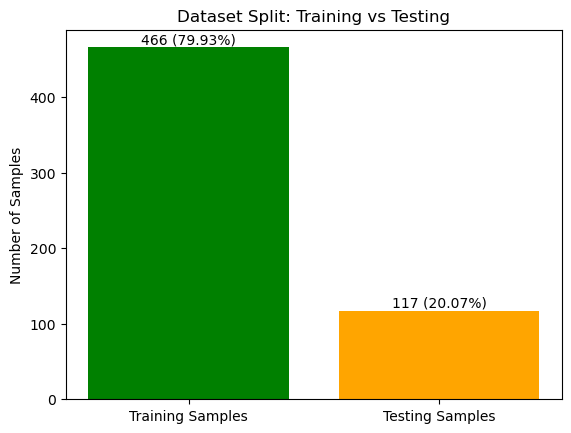

In [5]:
# Calculate the size and percentage of each split in the bar chart
train_samples = X_train.shape[0]
test_samples = X_test.shape[0]
total_samples = X.shape[0]
percentages = [train_samples / total_samples * 100, test_samples / total_samples * 100]

# Data for the bar chart
categories = ['Training Samples', 'Testing Samples']
values = [train_samples, test_samples] #Value variable here

# Create the bar chart
plt.bar(categories, values, color=['green', 'orange'])

# Add labels and title
plt.ylabel('Number of Samples') #Label for Y axis
plt.title('Dataset Split: Training vs Testing')# Title for the bar chart

# Show the counts and percentages on top of the bars
for i, (v, p) in enumerate(zip(values, percentages)):
    plt.text(i, v + 1, f"{v} ({p:.2f}%)", ha='center', va='bottom')

# Display the chart
plt.show()


# Make the TDIDF vectorizer here
**After making the TFIDF vectorizer, i want to find out the amount of matrix of token count there is, i have decided to use N-Gram value of 1 to 2 / ngram_range=(1,2) as this gives me more unique token to train the model compared to having of ngram of 1.**

**Then i wanted to check out some of the Feature name, count of data / docs used for training and testing is similiar to the bar chart above.**

**Same thing, i wanted to check if the count of unique token/words is similar to both the training and testing so there is no error**

**I will be setting a set seed of 42 for TFIDF Vectorizer and Model to make the result repeatable.**

In [6]:
# Initialize the TfidfVectorizer with stop words removal and n-gram range (1, 2)
tfidf = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))

# Fit and transform the training data into a TF-IDF matrix
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform the test data into a TF-IDF matrix
X_test_tfidf = tfidf.transform(X_test)

# Show the total count of data used and unique words/tokens
train_data, train_tokens = X_train_tfidf.toarray().shape
test_data, test_tokens = X_test_tfidf.toarray().shape

print(f"Training data: {train_data} documents, Unique tokens: {train_tokens}\n")
print(f"Test data: {test_data} documents, Unique tokens: {test_tokens}\n")
print(f"Feature names:\n{tfidf.get_feature_names_out()}")

Training data: 466 documents, Unique tokens: 8940

Test data: 117 documents, Unique tokens: 8940

Feature names:
['ability' 'able' 'able fly' ... 'zimbabwe zambia' 'zoonosis'
 'zoonosis singapore']


# Logistic Regression Model

**Reason for choosing logistic regression**

This dataset has a linear relationship between the features and its target class.

It is simple, fast when having large dataset and easily interpretableable.

It is computationally efficent when compared to other models, it provides probability for class predictions while being less prone to overfitting compared to other complex models like Decision Tree





In [7]:
from sklearn.linear_model import LogisticRegression

#Initialize the Logistic Regression
lr = LogisticRegression(solver='lbfgs',random_state=42)

# Train the Logistic Regression using the training data from count vectorizer
lr.fit(X_train_tfidf,y_train)

LogisticRegression(random_state=42)

In [8]:
# Make prediction using the Count Vectorizer test data
lr_pred = lr.predict(X_test_tfidf)#Predict using this data

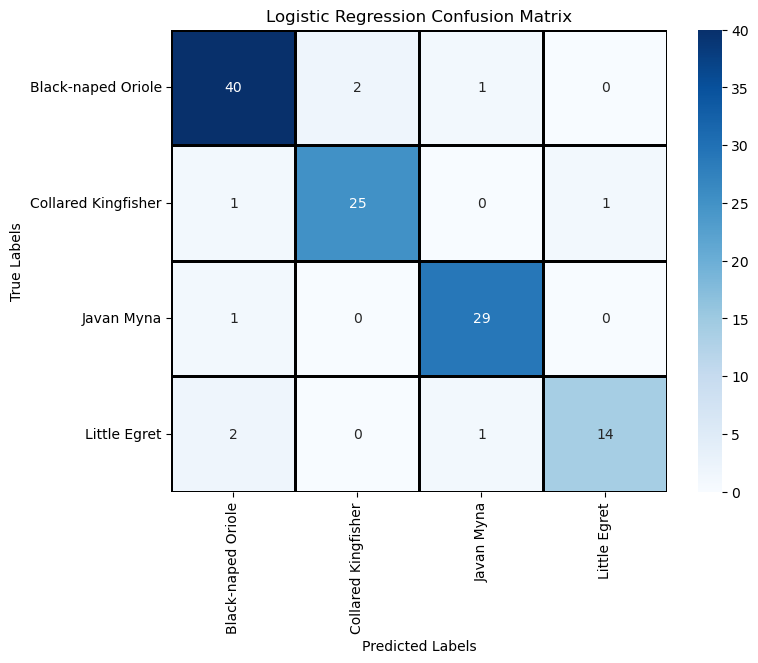

In [9]:
#Shows the confusion matrix
lr_cm = confusion_matrix(y_test,lr_pred)
# Create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test), linewidths=1, linecolor='black')

# Labels and title
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Show the plot
plt.show()

In [10]:
# Evaluate the model
print("Logistic Regression Classification Report:\n",classification_report(y_test,lr_pred,target_names=np.unique(Y)))

Logistic Regression Classification Report:
                      precision    recall  f1-score   support

 Black-naped Oriole       0.91      0.93      0.92        43
Collared Kingfisher       0.93      0.93      0.93        27
         Javan Myna       0.94      0.97      0.95        30
       Little Egret       0.93      0.82      0.88        17

           accuracy                           0.92       117
          macro avg       0.93      0.91      0.92       117
       weighted avg       0.92      0.92      0.92       117



# Naive Bayes Model
**Reason for choosing Naive Bayes Model**

Naive Bayes are very effective at document classification using text data.<br>
Since we have text data, and want to classify it to certain species. It will be suitable for this scenario.<br>

Naive Bayes is also good at dealing with high-dimensionality data due to it efficency.<br>
Since our data has 9035 Unique feature which makes it has a huge dimension. It is also very suited for this model

Naive Bayes is also good with working with insufficent data but have alot of features. Which fits my scenario.




In [11]:


# Initialize the Naive Bayes
nb = MultinomialNB() #Did not use seed 42 on this as this does not randomize the data when being used.

# Train the Naive Bayes classifier using the training data from count vectorizer
nb.fit(X_train_tfidf, y_train)

MultinomialNB()

In [12]:
# Make prediction using the Count Vectorizer test data
nb_pred = nb.predict(X_test_tfidf)#Predict using this data

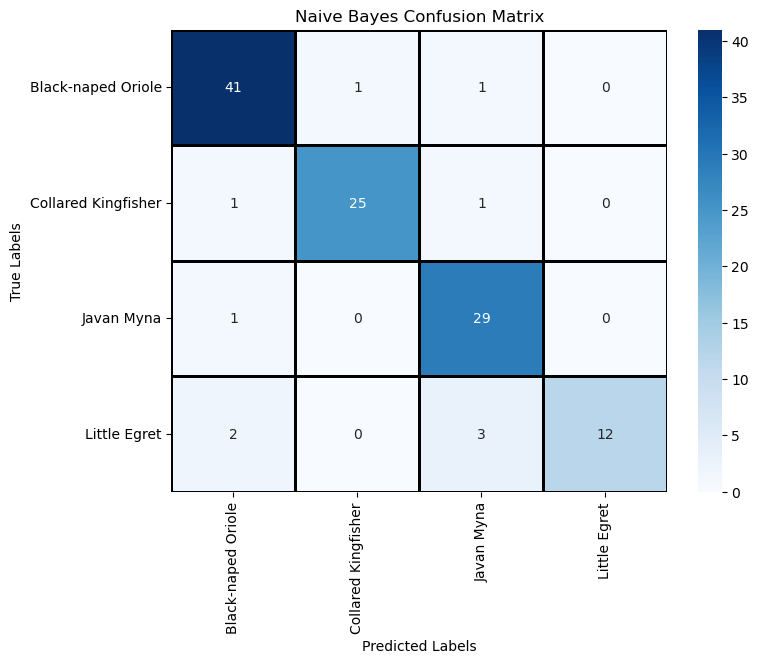

In [13]:
#Shows the confusion matrix
nb_cm = confusion_matrix(y_test,nb_pred)
# Create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(nb_cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test), linewidths=1, linecolor='black')

# Labels and title
plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Show the plot
plt.show()

In [14]:
# Evaluate the model
print("Naive Bayes Classification Report:\n",classification_report(y_test,nb_pred,target_names= np.unique(Y)))

Naive Bayes Classification Report:
                      precision    recall  f1-score   support

 Black-naped Oriole       0.91      0.95      0.93        43
Collared Kingfisher       0.96      0.93      0.94        27
         Javan Myna       0.85      0.97      0.91        30
       Little Egret       1.00      0.71      0.83        17

           accuracy                           0.91       117
          macro avg       0.93      0.89      0.90       117
       weighted avg       0.92      0.91      0.91       117



# SVM model
**Reason for choosing SVM model**<br>
SVM works accurately with high dimensional data and features, which our data has 9,305 unique feature. So it fits our use case.<br>
SVM can also effective when classes are not linearly seperable. In out case we have alot of dimensions which might be use.


In [15]:
# Initialize the SVM model
svm_model = SVC(kernel='linear', random_state=42,probability=True)

# Train the SVM using the training data from count vectorizer
svm_model.fit(X_train_tfidf, y_train)

SVC(kernel='linear', probability=True, random_state=42)

In [16]:
# Make prediction using the Count Vectorizer test data
svm_pred = svm_model.predict(X_test_tfidf)#Predict using this data

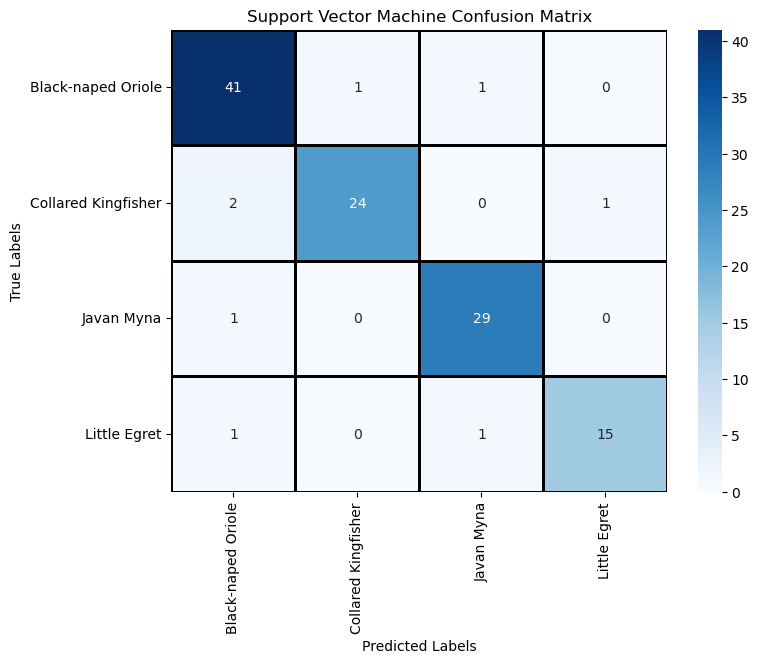

In [17]:
#Shows the confusion matrix
svm_cm = confusion_matrix(y_test,svm_pred)
# Create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test), linewidths=1, linecolor='black')

# Labels and title
plt.title('Support Vector Machine Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Show the plot
plt.show()

In [18]:
# Evaluate the model
print("Support Vector Machine Classification Report:\n", classification_report(y_test, svm_pred,target_names= np.unique(Y)))

Support Vector Machine Classification Report:
                      precision    recall  f1-score   support

 Black-naped Oriole       0.91      0.95      0.93        43
Collared Kingfisher       0.96      0.89      0.92        27
         Javan Myna       0.94      0.97      0.95        30
       Little Egret       0.94      0.88      0.91        17

           accuracy                           0.93       117
          macro avg       0.94      0.92      0.93       117
       weighted avg       0.93      0.93      0.93       117



# Decision Tree Model
**Reason for choosing Decision Tree Model**<br>
Decision Tree works well with both classification and regression tasks and it is also easily intepreted.
Decision Tree breaks down the classification process into a yes/no questions which works well with out use case.<br> Example, which of this text belongs to which species in our scenario. <br>

Decision Tree can also handle categorical features and continous ones. Which makes it flexble for handling diverse type of data we have here. 



In [19]:
# Initialize the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the Decision Tree using the training data from count vectorizer
dt_model.fit(X_train_tfidf, y_train)


DecisionTreeClassifier(random_state=42)

In [20]:
# Make prediction using the Count Vectorizer test data
dt_pred = dt_model.predict(X_test_tfidf) #Predict using this data

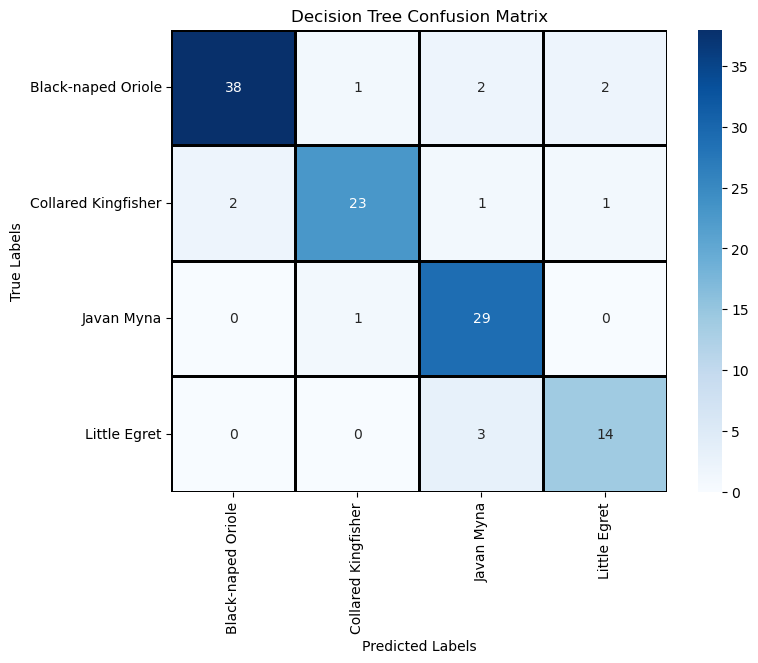

In [21]:
#Shows the confusion matrix
dt_cm = confusion_matrix(y_test,dt_pred)
# Create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test), linewidths=1, linecolor='black')

# Labels and title
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Show the plot
plt.show()

In [22]:
# Evaluate the model
print("Decision Tree Classification Report:\n", classification_report(y_test, dt_pred,target_names= np.unique(Y)))

Decision Tree Classification Report:
                      precision    recall  f1-score   support

 Black-naped Oriole       0.95      0.88      0.92        43
Collared Kingfisher       0.92      0.85      0.88        27
         Javan Myna       0.83      0.97      0.89        30
       Little Egret       0.82      0.82      0.82        17

           accuracy                           0.89       117
          macro avg       0.88      0.88      0.88       117
       weighted avg       0.89      0.89      0.89       117



# Comparision between Models

I have written the code here to compare the 4 models that i have created.

**Decision Tree, Support Vector Machine (SVM), Navie Bayes, Logistic Regression**

After comparing Accuracy, Precision, Recall and F1-Score. I have decided that Logistic Regression is the best model.

When Looking at **Accuracy** SVM has the highest score of 0.931624 which indicates out of these 4 models. Since SVM has the highest accuracy among the 4 models it predict the species the most accurate among the other models.

But when you compare **Precision** which is how accurate the positive prediction of the models are, SVM is the  highest at 0.0.936024 while Navie Bayes being the second highest score, 0.931398. Despite SVM being the best, Naive Bayes score is very close to it. Overall, SVM has the highest Precision.

Comparing **Recall** which indicate how good it is at identifying positive cases, SVM having the highest value, 0.922849. Which means it is the best model at identifying positive cases / correct species in this scenario.

Lastly, **F1-score**. SVM being the highest, 0.928701. While Logistic Regression having the second highest score, 0.917821. This suggest that it has both SVM and Logistic Regression have a good balance between precision and recall. Overall, SVM has the highest F1-score.

Overall, when looking holistically. We can see that SVM is the best performing model with these 4 metrics that i have compared with.

**Hence i will be taking SVM as best model.**


In [23]:
# Calculate accuracy for each model
dt_accuracy = accuracy_score(y_test, dt_pred)
svm_accuracy = accuracy_score(y_test, svm_pred)
nb_accuracy = accuracy_score(y_test, nb_pred)
lr_accuracy = accuracy_score(y_test, lr_pred)

# Generate classification reports for each model
dt_report = classification_report(y_test, dt_pred, output_dict=True)
svm_report = classification_report(y_test, svm_pred, output_dict=True)
nb_report = classification_report(y_test, nb_pred, output_dict=True)
lr_report = classification_report(y_test, lr_pred, output_dict=True)

# Dictionary of all the values before coverting it to DataFrame
overall_comparison = {
    "Metric": ["Accuracy","Precision", "Recall", "F1-Score"],
    "Decision Tree": [dt_accuracy,dt_report['macro avg']['precision'], dt_report['macro avg']['recall'], dt_report['macro avg']['f1-score']],
    "SVM": [svm_accuracy,svm_report['macro avg']['precision'], svm_report['macro avg']['recall'], svm_report['macro avg']['f1-score']],
    "Naive Bayes": [nb_accuracy,nb_report['macro avg']['precision'], nb_report['macro avg']['recall'], nb_report['macro avg']['f1-score']],
    "Logistic Regression": [lr_accuracy,lr_report['macro avg']['precision'], lr_report['macro avg']['recall'], lr_report['macro avg']['f1-score']]
}
#Converting it to DataFrame for easier viewing
overall_comparison_df = pd.DataFrame(overall_comparison)
overall_comparison_df


,Metric,Decision Tree,SVM,Naive Bayes,Logistic Regression
0,Accuracy,0.888889,0.931624,0.914530,0.923077
1,Precision,0.880525,0.936024,0.931398,0.925959
2,Recall,0.881442,0.922849,0.887991,0.911589
3,F1-Score,0.879029,0.928701,0.902263,0.917821


# Exporting TFIDF Vectorizer and SVM Model

In [24]:
# Specify the target path
model_path = r'C:/Users/zhoul/Y2 Sem2/IT2391 NLP/IT2391_234707R_Assignment/Models'

# Get the current timestamp
time = datetime.now().strftime("%Y-%m-%d")

# Create filenames with timestamps
svm_filename = f'SVM-{time}.pkl'  # Logistic Regression model
tfidf_filename = f'TFIDF-{time}.pkl'  # Count Vectorizer

# Full file paths
svm_path = os.path.join(model_path, svm_filename)
tfidf_path = os.path.join(model_path, tfidf_filename)

# Save Logistic Regression model
with open(svm_path, 'wb') as f1:
    pickle.dump(svm_model, f1)

# Save Count Vectorizer
with open(tfidf_path, 'wb') as f2:
    pickle.dump(tfidf, f2)

print(f"Logistic Regression model saved to: {svm_path}")
print(f"Count Vectorizer saved to: {tfidf_path}")

Logistic Regression model saved to: C:/Users/zhoul/Y2 Sem2/IT2391 NLP/IT2391_234707R_Assignment/Models\SVM-2024-12-13.pkl
Count Vectorizer saved to: C:/Users/zhoul/Y2 Sem2/IT2391 NLP/IT2391_234707R_Assignment/Models\TFIDF-2024-12-13.pkl
